In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Model, load_model # type: ignore
import matplotlib.pyplot as plt
import os
import json
from PIL import Image
import shutil
from pathlib import Path

In [2]:
print("--- GPU Detection Status ---")
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

--- GPU Detection Status ---
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [3]:
# source_dirs = '/content/drive/MyDrive/Colab Notebooks/project_folder/plantvillage dataset/color'
source_dirs = r'C:\NEWHELPTHEGREEN\health_classifier'

In [4]:
#Step 3: Data generators with augmentations
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # type: ignore

image_size = 128
batch_size = 8
train_dir = 'health_classifier/train'
val_dir = 'health_classifier/val'

# --- 1. Define Augmentation without validation_split ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
    zoom_range=0.3,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# --- 2. Define Validation Generator (Only Rescaling) ---
val_datagen = ImageDataGenerator(rescale=1./255) 

# --- 3. Create Training Generator ---
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

# --- 4. Create Validation Generator ---
# IMPORTANT: Now points directly to the 'val' folder
val_gen = val_datagen.flow_from_directory(
    val_dir, # <-- FIX: Points to 'health_classifier/val'
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
    # REMOVED: subset='validation'
)

num_classes = train_gen.num_classes

print(f"Number of classes detected: {num_classes}")
print(f"Classes found by generator: {train_gen.class_indices}")

Found 4944 images belonging to 2 classes.
Found 1028 images belonging to 2 classes.
Number of classes detected: 2
Classes found by generator: {'diseased': 0, 'healthy': 1}


In [5]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.layers import BatchNormalization # type: ignore #
from tensorflow.keras import layers, models # type: ignore
import json

# Define the model architecture for hyperparameter tuning
def build_model(hp):
    model = models.Sequential()
    
    # --- Conv Block 1 ---
    # FIX: BatchNormalization is now correctly placed after the Conv2D layer
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', 32, 128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(image_size, image_size, 3)
    ))
    model.add(BatchNormalization()) 
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 2 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', 64, 256, step=64),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 3 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_3_filters', 128, 512, step=128),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(
        hp.Int('dense_units', 128, 512, step=128),
        activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='HelpTheGreen'
)

print("Starting Hyperparameter Search (3 Trials x 5 Epochs each)...")
tuner.search(train_gen, epochs=5, validation_data=val_gen)
print("Hyperparameter Search Complete.")

# Get the best model and train it for 5 epochs
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")
model = tuner.hypermodel.build(best_hps)

print("\nStarting Final Model Training (5 Epochs)...")
history = model.fit(train_gen, epochs=5, validation_data=val_gen)

# Save model and class labels locally
model.save('plantvillage_tuned_model.h5')
class_labels = {v: k for k, v in train_gen.class_indices.items()}

with open('class_labels_combined.json', 'w') as f:
    json.dump(class_labels, f)

print("Final tuned model and class labels saved locally.")

Reloading Tuner from keras_tuner_dir\HelpTheGreen\tuner0.json
Starting Hyperparameter Search (3 Trials x 5 Epochs each)...
Hyperparameter Search Complete.

Best hyperparameters found:
conv_1_filters: 128
conv_2_filters: 192
conv_3_filters: 384
dense_units: 512
dropout: 0.4
learning_rate: 0.00010134724629631065

Starting Final Model Training (5 Epochs)...
Epoch 1/5
618/618 [==============================] - 172s 249ms/step - loss: 2.2049 - accuracy: 0.5920 - val_loss: 0.7156 - val_accuracy: 0.6245
Epoch 2/5
618/618 [==============================] - 95s 154ms/step - loss: 0.7540 - accuracy: 0.6278 - val_loss: 0.6271 - val_accuracy: 0.6294
Epoch 3/5
618/618 [==============================] - 90s 146ms/step - loss: 0.6374 - accuracy: 0.6586 - val_loss: 0.5202 - val_accuracy: 0.6984
Epoch 4/5
618/618 [==============================] - 75s 122ms/step - loss: 0.7317 - accuracy: 0.6578 - val_loss: 0.6472 - val_accuracy: 0.6819
Epoch 5/5
618/618 [==============================] - 82s 132ms/ste

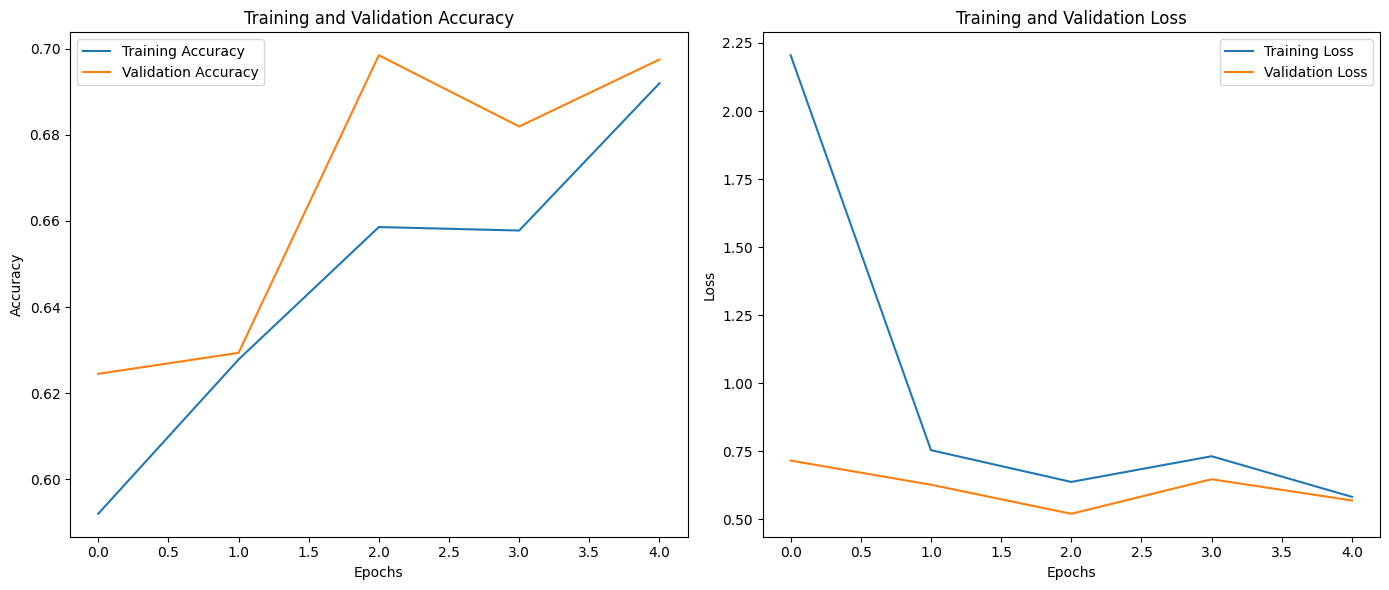

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

plot_history(history)


In [7]:
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Training Accuracy:  {history.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy:{history.history['val_accuracy'][epoch]:.4f}")
    print(f"  Training Loss:      {history.history['loss'][epoch]:.4f}")
    print(f"  Validation Loss:    {history.history['val_loss'][epoch]:.4f}")


Epoch 1:
  Training Accuracy:  0.5920
  Validation Accuracy:0.6245
  Training Loss:      2.2049
  Validation Loss:    0.7156
Epoch 2:
  Training Accuracy:  0.6278
  Validation Accuracy:0.6294
  Training Loss:      0.7540
  Validation Loss:    0.6271
Epoch 3:
  Training Accuracy:  0.6586
  Validation Accuracy:0.6984
  Training Loss:      0.6374
  Validation Loss:    0.5202
Epoch 4:
  Training Accuracy:  0.6578
  Validation Accuracy:0.6819
  Training Loss:      0.7317
  Validation Loss:    0.6472
Epoch 5:
  Training Accuracy:  0.6919
  Validation Accuracy:0.6975
  Training Loss:      0.5825
  Validation Loss:    0.5692


In [9]:
# Prediction
# Prediction
import numpy as np
import json
from PIL import Image
from tensorflow.keras.models import load_model  # type: ignore
import tensorflow as tf # <-- Ensure this is imported

# --- FIX IS HERE ---
def load_preprocess_image(image_path, target_size=(128, 128)): # <-- CHANGE 254 to 128
# --------------------
    # Load the image and convert to RGB
    img = Image.open(image_path).convert("RGB")
    # Resize the image
    img = img.resize(target_size)
    # Convert to NumPy array
    img_array = np.array(img)
    # Add a batch dimension (1, H, W, C)
    img_array = np.expand_dims(img_array, axis=0)
    # Normalize the pixel values to 0-1
    img_array = img_array.astype('float32') / 255
    return img_array

def predict_image(image_path):
    # --- CRITICAL FIX: Load the model onto the CPU first ---
    with tf.device('/CPU:0'):
        model = load_model(r'C:\NEWHELPTHEGREEN\plantvillage_tuned_model.h5')
    
    # Load the class labels from the local file where it was saved
    with open('class_labels_combined.json', 'r') as f:
        class_labels = json.load(f)
        class_labels = {int(k): v for k, v in class_labels.items()}

    img_array = load_preprocess_image(image_path)
    
    # The prediction will still run on the GPU if possible (the default behavior)
    prediction = model.predict(img_array) 
    
    print("Top 3 Predictions:")
    top_3 = np.argsort(prediction[0])[-3:][::-1]
    
    for i in top_3:
        class_name = class_labels[i]
        confidence = prediction[0][i]
        print(f"{class_name}: {confidence:.2%}")


# Run the prediction using your test image
predict_image(r'C:\NEWHELPTHEGREEN\11.jpg')

1/1 [==============================] - 3s 3s/step
Top 3 Predictions:
diseased: 97.83%
healthy: 2.17%
